# Supplier Price Prediction in Multi-Round Negotiations
## A Comprehensive Data Analysis Report

**Objective:** Predict the supplier's current price response `s_t` from negotiation covariates, diagnose collinearity and overfitting risks, and select a parsimonious yet accurate model.

In [2]:
import json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (LeaveOneGroupOut, cross_val_predict,
                                      KFold, cross_val_score, GridSearchCV)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [7]:
def load_data(pa):
    trans = []
    data = json.load(open(pa, encoding="utf-8"))
    for ri, run in enumerate(data["runs"]):
        meta = run["metadata"]
        v = meta["v"]; cost = meta["product"]["cost"]; market = meta["product"]["market_price"]
        rounds = run["rounds"]
        m_init = rounds[0]["buyer_price"]; s_init = rounds[0]["supplier_price"]
        for i in range(1, len(rounds)):
            prev, curr = rounds[i-1], rounds[i]
            sp, mc, sc = prev["supplier_price"], curr["buyer_price"], curr["supplier_price"]
            if sp is None or sc is None:
                continue
            trans.append(dict(
                m_t=mc, s_prev=sp, s_t=sc, v=v, cost=cost, market=market,
                round_t=curr["round"], buyer_type=meta["buyer_type"]["name"],
                product=meta["product"]["name"], supplier_id=meta["supplier"]["id"],
                m_init=m_init, s_init=s_init if s_init else np.nan,
                m_prev=prev["buyer_price"], template_id=curr.get("template_id", -1),
                s_prev2=rounds[i-2]["supplier_price"] if i >= 2 else None,
                run_idx=ri,
                m_prev2=rounds[i-2]["buyer_price"] if i >= 2 else None,
                s_prev3=rounds[i-3]["supplier_price"] if i >= 3 else None,
                m_prev3=rounds[i-3]["buyer_price"] if i >= 3 else None
            ))
    return trans

all_data_S1 = load_data("cooperative/random__protein__S1.json")
all_data_S2= load_data("cooperative/random__protein__S2.json")
all_data_cola_S1 = load_data("cooperative/random__cola__S1.json")
all_data_cola_S2 = load_data("cooperative/random__cola__S2.json")

all_data = all_data_S1 + all_data_S2 + all_data_cola_S1 + all_data_cola_S2
df = pd.DataFrame(all_data)
df['region'] = np.where(df['m_t'] < df['v'], 'Low',
                np.where(df['m_t'] > df['s_prev'], 'High', 'Negotiation'))
print(f"Dataset: {df.shape[0]} observations × {df.shape[1]} columns")
print(f"Runs: {df['run_idx'].nunique()}, samples per run: {df.groupby('run_idx').size().unique()}")
print(df.head(5))


Dataset: 438 observations × 20 columns
Runs: 10, samples per run: [43 44]
    m_t  s_prev   s_t    v  cost  market  round_t buyer_type  \
0  1.97    2.20  2.10  1.7   1.1     3.0        2     random   
1  2.69    2.10  2.69  1.7   1.1     3.0        3     random   
2  1.85    2.69  2.05  1.7   1.1     3.0        4     random   
3  2.22    2.05  2.22  1.7   1.1     3.0        5     random   
4  2.93    2.22  2.93  1.7   1.1     3.0        6     random   

             product supplier_id  m_init  s_init  m_prev  template_id  \
0  Protein bar (60g)          S1    1.54     2.2    1.54            6   
1  Protein bar (60g)          S1    1.54     2.2    1.97            5   
2  Protein bar (60g)          S1    1.54     2.2    2.69            4   
3  Protein bar (60g)          S1    1.54     2.2    1.85            1   
4  Protein bar (60g)          S1    1.54     2.2    2.22            6   

   s_prev2  run_idx  m_prev2  s_prev3  m_prev3       region  
0      NaN        0      NaN      NaN   

# Some Quick EDA

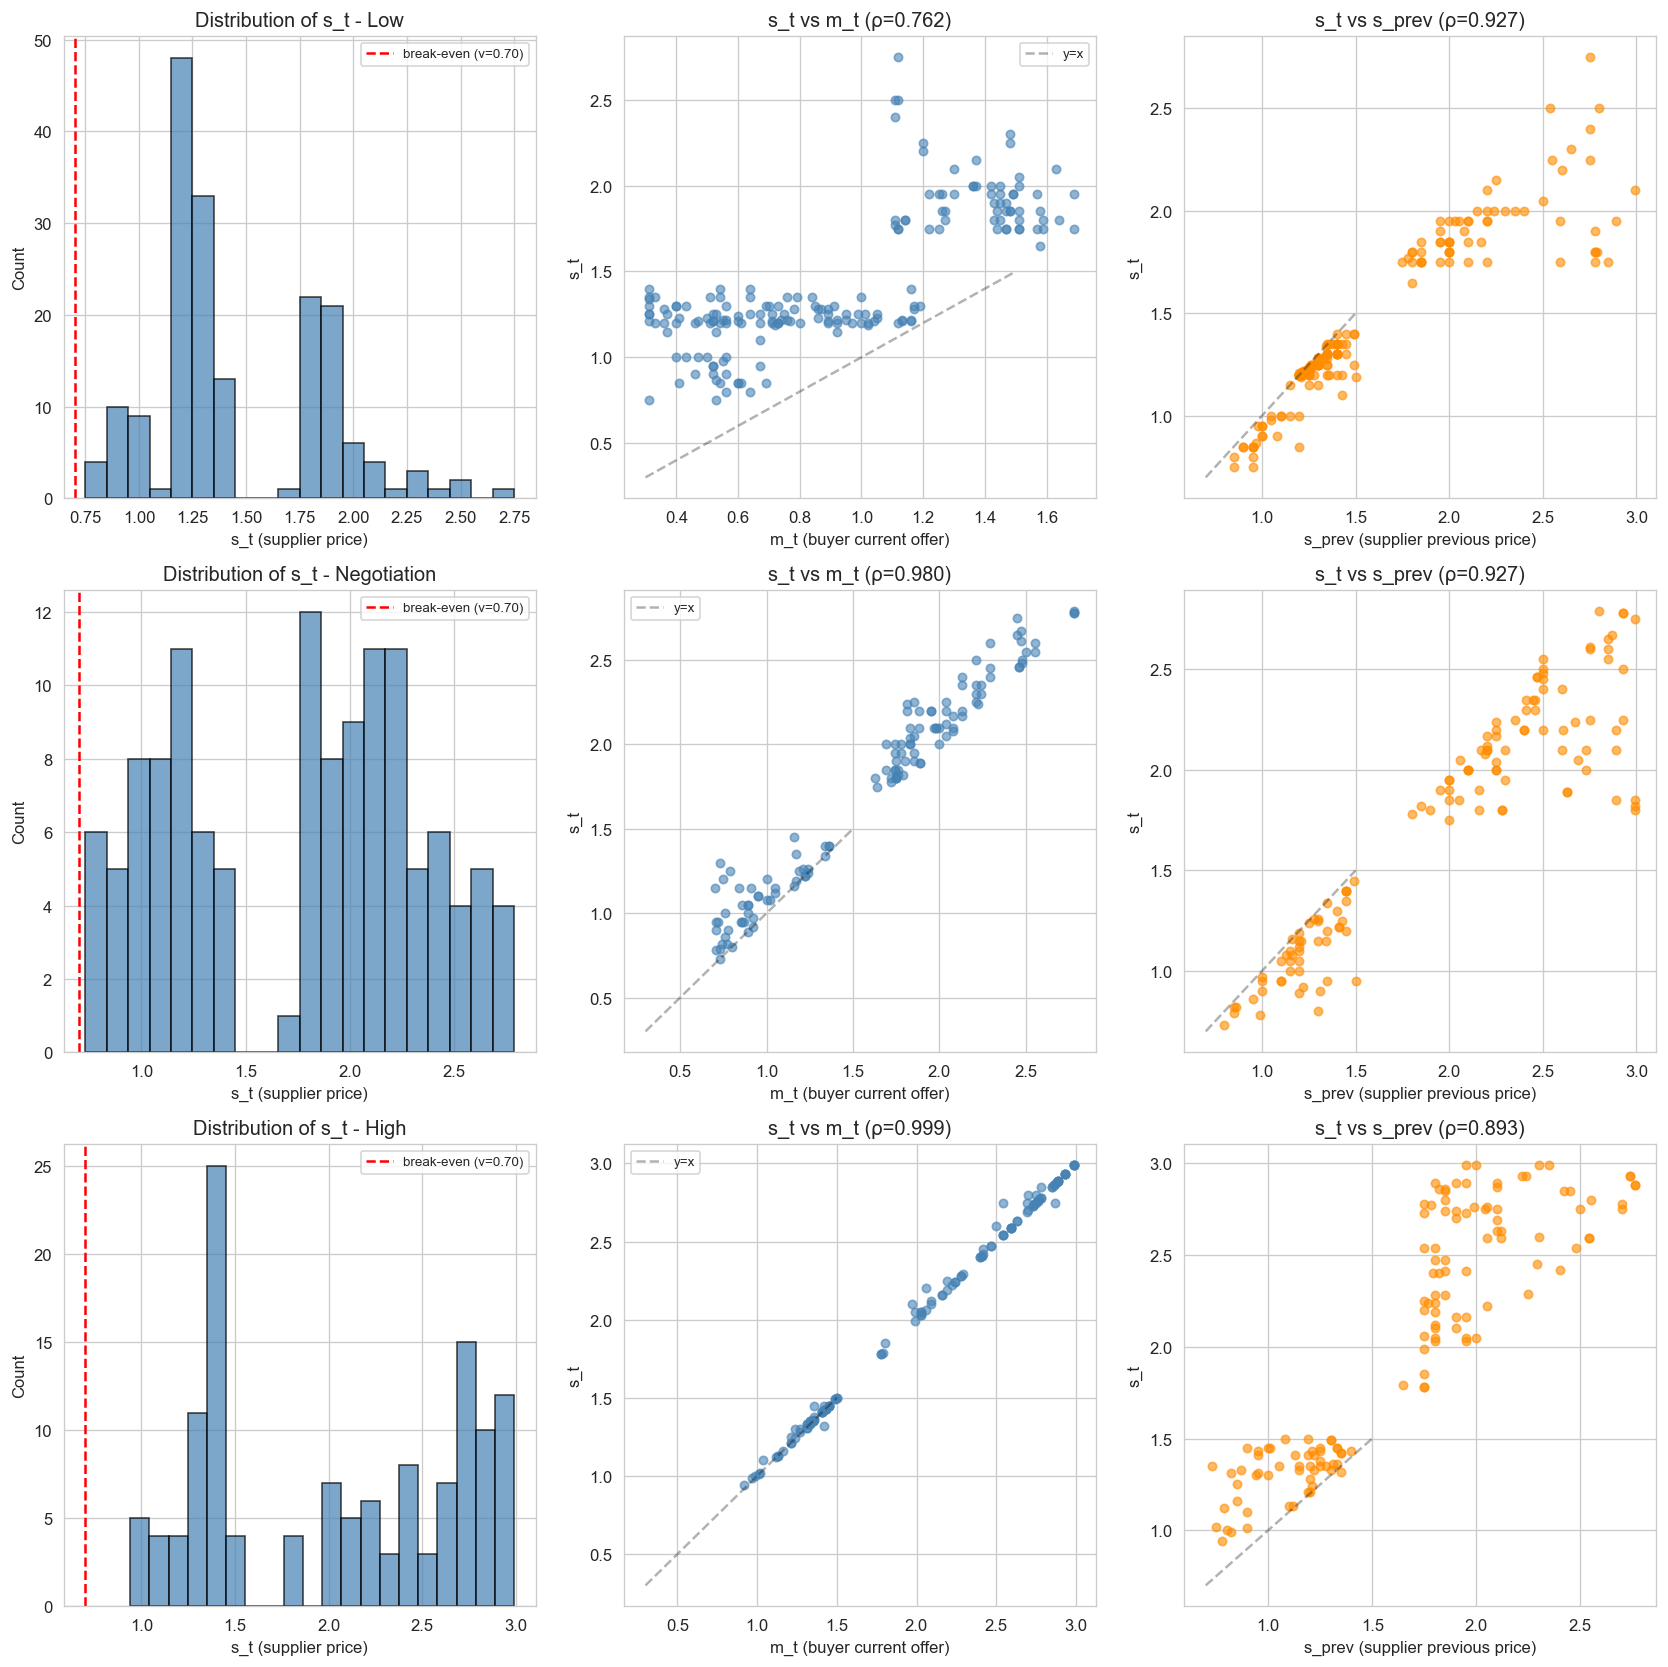

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 14))

regions = ['Low', 'Negotiation', 'High']
for i in range(3):
    df_region = df[df['region'] == regions[i]]

    axes[i, 0].hist(df_region['s_t'], bins=20, edgecolor='k', alpha=0.7, color='steelblue')
    axes[i, 0].set_xlabel('s_t (supplier price)')
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].set_title(f'Distribution of s_t - {regions[i]}')
    axes[i, 0].axvline(0.70, color='red', ls='--', label='break-even (v=0.70)')
    axes[i, 0].legend(fontsize=8)

    corr_mt_st = df_region[['m_t', 's_t']].corr().iloc[0, 1]
    axes[i, 1].scatter(df_region['m_t'], df_region['s_t'], alpha=0.6, s=25, c='steelblue')
    axes[i, 1].set_xlabel('m_t (buyer current offer)')
    axes[i, 1].set_ylabel('s_t')
    axes[i, 1].set_title(f's_t vs m_t (ρ={corr_mt_st:.3f})')
    axes[i, 1].plot([0.3, 1.5], [0.3, 1.5], 'k--', alpha=0.3, label='y=x')
    axes[i, 1].legend(fontsize=8)

    corr_sprev_st = df_region[['s_prev', 's_t']].corr().iloc[0, 1]
    axes[i, 2].scatter(df_region['s_prev'], df_region['s_t'], alpha=0.6, s=25, c='darkorange')
    axes[i, 2].set_xlabel('s_prev (supplier previous price)')
    axes[i, 2].set_ylabel('s_t')
    axes[i, 2].set_title(f's_t vs s_prev (ρ={corr_sprev_st:.3f})')
    axes[i, 2].plot([0.7, 1.5], [0.7, 1.5], 'k--', alpha=0.3)

plt.tight_layout()
plt.show()

Let's focus on the low and negotiation region. The high region is not very interesting

## 2. Model Development

### Strategy
Focus on low and negotiation region. Given the small sample and moderate collinearity, we pursue a disciplined model comparison:

1. **Baseline:** Naïve predictors (mean, previous supplier price)
2. **Linear models:** OLS, Ridge, Lasso, ElasticNet — to address collinearity
3. **Nonlinear models:** Decision Tree, Random Forest, Gradient Boosting
4. **Feature engineering:** Polynomial/interaction terms with regularisation
5. **Cross-validation:** Leave-One-Group-Out (LOGO) by `run_idx` to prevent within-run leakage

We focus on the **core feature set** (no lag-3, minimal missing data) and then check if lags add value.

In [17]:
# ── Feature sets ──
core_features = ['m_t', 's_prev', 'round_t', 'm_prev', 'v']
lag2_features = core_features + ['s_prev2', 'm_prev2']

# Core dataset (no missing)
df_core = df[df['region'] != "High"].copy()
y_core = df_core['s_t'].values
X_core = df_core[core_features].values
groups_core = df[df['region'] != "High"]['run_idx'].values

# Lag-2 dataset
df_lag2 =  df[df['region'] != "High"].dropna(subset=['s_prev2', 'm_prev2']).copy()
y_lag2 = df_lag2['s_t'].values
X_lag2 = df_lag2[lag2_features].values
groups_lag2 = df[df['region'] != "High"].loc[df_lag2.index, 'run_idx'].values

print(f"Core dataset: {X_core.shape}")
print(f"Lag-2 dataset: {X_lag2.shape}")


Core dataset: (305, 5)
Lag-2 dataset: (269, 7)


In [18]:
def evaluate_models(X, y, groups, feature_names, label=''):
    """Run LOGO-CV for a suite of models and return results DataFrame."""
    logo = LeaveOneGroupOut()
    
    models = {
        'Mean baseline':       None,  # handled separately
        's_prev baseline':     None,
        'm_t baseline':       None,
        'OLS':                 Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
        'Ridge (α=1)':         Pipeline([('scaler', StandardScaler()), ('lr', Ridge(alpha=1.0))]),
        'Ridge (α=10)':        Pipeline([('scaler', StandardScaler()), ('lr', Ridge(alpha=10.0))]),
        'Lasso (α=0.01)':      Pipeline([('scaler', StandardScaler()), ('lr', Lasso(alpha=0.01, max_iter=10000))]),
        'Lasso (α=0.1)':       Pipeline([('scaler', StandardScaler()), ('lr', Lasso(alpha=0.1, max_iter=10000))]),
        'ElasticNet':          Pipeline([('scaler', StandardScaler()), ('lr', ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000))]),
        'Decision Tree (d=3)': DecisionTreeRegressor(max_depth=3, random_state=42),
        'Random Forest':       RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1),
        'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42),
    }
    
    results = []
    preds_dict = {}
    
    for name, model in models.items():
        if name == 'Mean baseline':
            # predict group-wise mean from training folds
            preds = np.zeros_like(y)
            for train_idx, test_idx in logo.split(X, y, groups):
                preds[test_idx] = y[train_idx].mean()
        elif name == 's_prev baseline':
            fi = feature_names.index('s_prev')
            preds = X[:, fi].copy()
        elif name == 'm_t baseline':
            fi = feature_names.index('m_t')
            preds = X[:, fi].copy()
        else:
            preds = cross_val_predict(model, X, y, cv=logo, groups=groups)
        
        rmse = np.sqrt(mean_squared_error(y, preds))
        mae = mean_absolute_error(y, preds)
        r2 = r2_score(y, preds)
        results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
        preds_dict[name] = preds
    
    res_df = pd.DataFrame(results).sort_values('RMSE')
    return res_df, preds_dict

print("Evaluation framework ready.")

Evaluation framework ready.


### 2.1 Model Comparison — Core Features

In [19]:
res_core, preds_core = evaluate_models(X_core, y_core, groups_core, core_features, 'Core')

print("=" * 65)
print("LOGO-CV Results — Core Features")
print("=" * 65)
print(res_core.to_string(index=False, float_format='{:.4f}'.format))


LOGO-CV Results — Core Features
              Model   RMSE    MAE      R²
  Gradient Boosting 0.1093 0.0720  0.9538
      Random Forest 0.1243 0.0803  0.9402
Decision Tree (d=3) 0.1427 0.1025  0.9213
        Ridge (α=1) 0.1450 0.1051  0.9187
                OLS 0.1451 0.1049  0.9186
       Ridge (α=10) 0.1452 0.1062  0.9185
     Lasso (α=0.01) 0.1453 0.1051  0.9184
         ElasticNet 0.1497 0.1097  0.9134
      Lasso (α=0.1) 0.1874 0.1446  0.8642
    s_prev baseline 0.2925 0.1746  0.6693
       m_t baseline 0.4676 0.3612  0.1549
      Mean baseline 0.5096 0.4534 -0.0035


### 2.2 Model Comparison — With Lag-2 Features

In [20]:
res_lag2, preds_lag2 = evaluate_models(X_lag2, y_lag2, groups_lag2, lag2_features, 'Lag2')

print("=" * 65)
print("LOGO-CV Results — Lag-2 Features")
print("=" * 65)
print(res_lag2.to_string(index=False, float_format='{:.4f}'.format))


LOGO-CV Results — Lag-2 Features
              Model   RMSE    MAE      R²
  Gradient Boosting 0.1125 0.0762  0.9505
      Random Forest 0.1254 0.0836  0.9386
       Ridge (α=10) 0.1447 0.1079  0.9181
        Ridge (α=1) 0.1454 0.1077  0.9174
                OLS 0.1457 0.1077  0.9171
     Lasso (α=0.01) 0.1462 0.1072  0.9164
         ElasticNet 0.1502 0.1107  0.9118
Decision Tree (d=3) 0.1597 0.1158  0.9003
      Lasso (α=0.1) 0.1906 0.1450  0.8580
    s_prev baseline 0.3057 0.1812  0.6347
       m_t baseline 0.4767 0.3683  0.1117
      Mean baseline 0.5065 0.4525 -0.0028


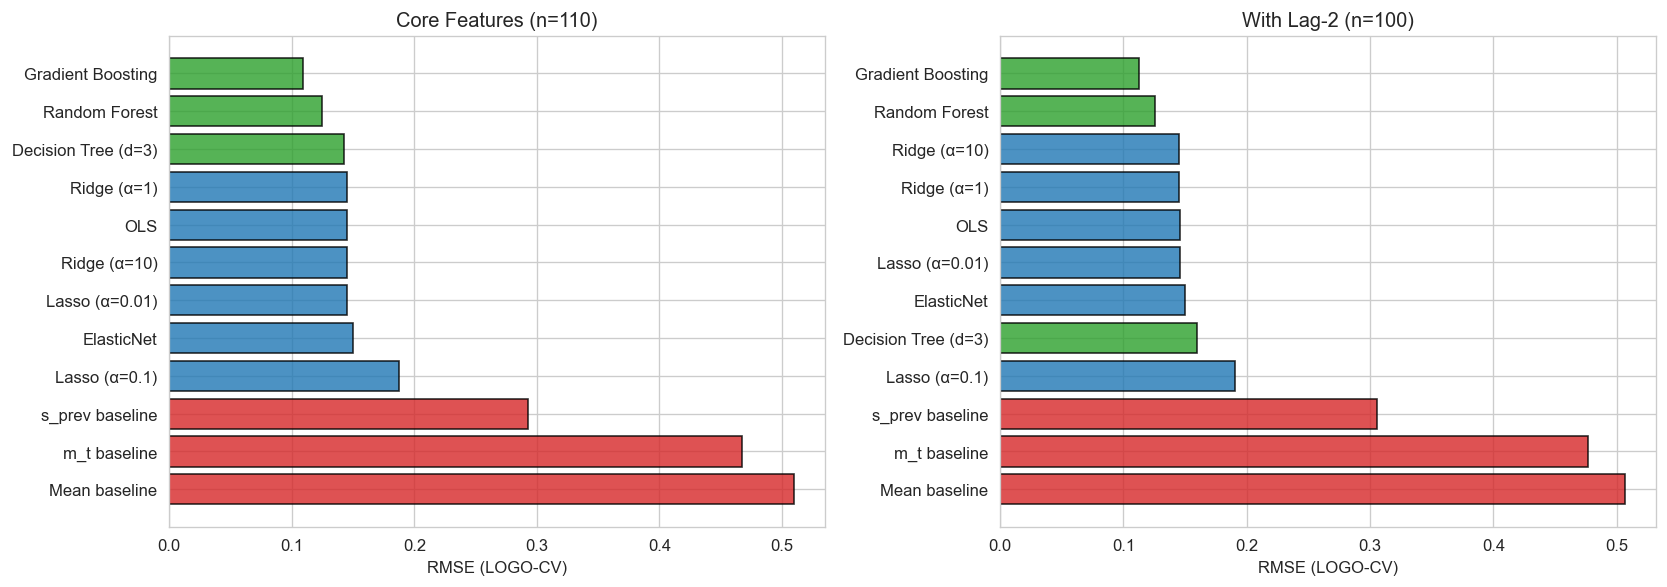

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in [(axes[0], res_core, 'Core Features (n=110)'),
                        (axes[1], res_lag2, 'With Lag-2 (n=100)')]:
    colors = ['#d62728' if 'baseline' in m else '#1f77b4' if any(k in m for k in ['OLS','Ridge','Lasso','Elastic']) else '#2ca02c'
              for m in res['Model']]
    ax.barh(res['Model'], res['RMSE'], color=colors, edgecolor='k', alpha=0.8)
    ax.set_xlabel('RMSE (LOGO-CV)')
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout(); plt.show()

### 2.4 Feature Importance

Intercept: 1.5678
Feature  Coefficient (standardised)  |Coefficient|
 s_prev                      0.2488         0.2488
    m_t                      0.1445         0.1445
      v                      0.1238         0.1238
round_t                     -0.0516         0.0516
 m_prev                      0.0011         0.0011


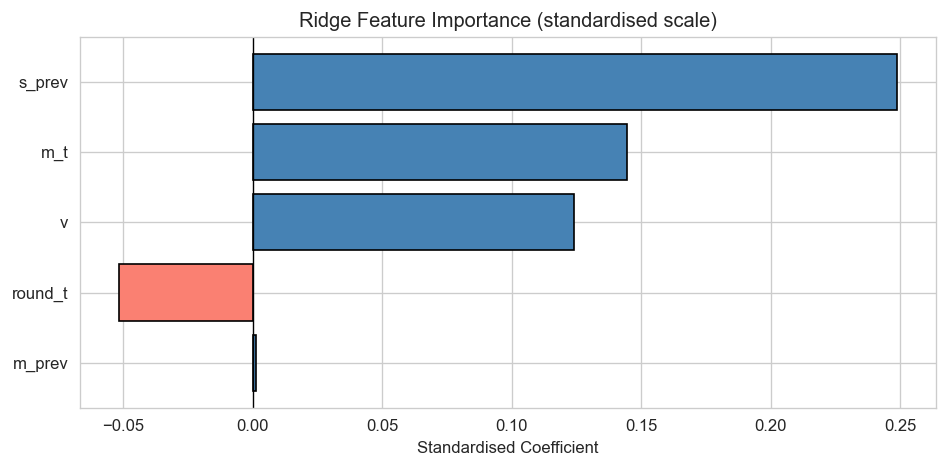

In [22]:
# Fit on full data with best alpha
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_core)
ridge_best = Ridge(alpha=0.001)
ridge_best.fit(X_scaled, y_core)

coef_df = pd.DataFrame({
    'Feature': core_features,
    'Coefficient (standardised)': ridge_best.coef_,
    '|Coefficient|': np.abs(ridge_best.coef_)
}).sort_values('|Coefficient|', ascending=False)

print(f"Intercept: {ridge_best.intercept_:.4f}")
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient (standardised)']]
ax.barh(coef_df['Feature'], coef_df['Coefficient (standardised)'], color=colors, edgecolor='k')
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Ridge Feature Importance (standardised scale)')
ax.axvline(0, color='k', lw=0.8)
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 2.5 Polynomial Feature Expansion + Regularisation

We test whether quadratic terms and two-way interactions improve prediction, using Ridge to control the expanded dimensionality.

Best Poly-2 Ridge: α=0.13, RMSE=0.1009, R²=0.9607


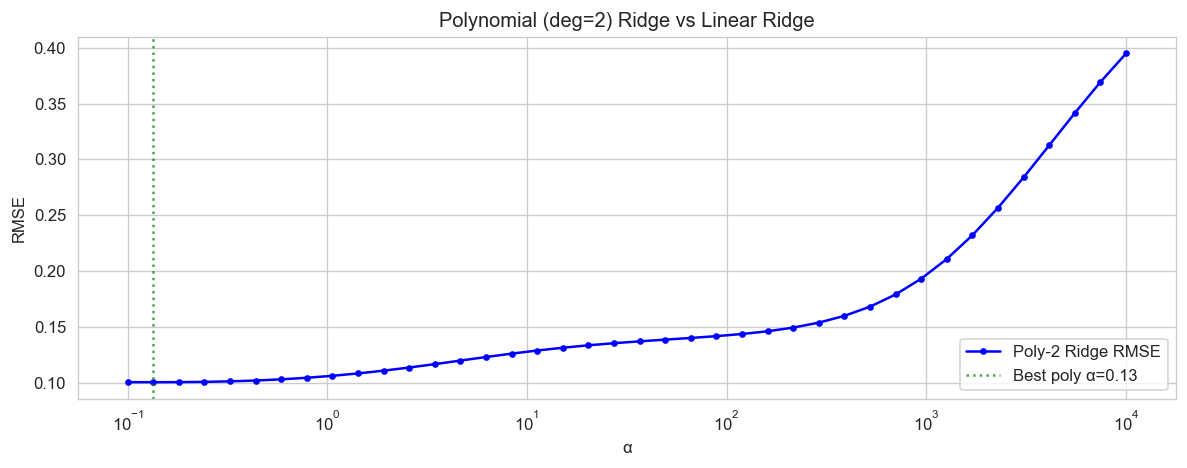

In [23]:
# Degree-2 polynomial features with Ridge
poly_alphas = np.logspace(-1, 4, 40)
poly_scores = []

for a in poly_alphas:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    preds = cross_val_predict(pipe, X_core, y_core, cv=LeaveOneGroupOut(), groups=groups_core)
    rmse = np.sqrt(mean_squared_error(y_core, preds))
    r2 = r2_score(y_core, preds)
    poly_scores.append({'alpha': a, 'RMSE': rmse, 'R2': r2})

poly_df = pd.DataFrame(poly_scores)
best_poly_idx = poly_df['RMSE'].idxmin()
best_poly_alpha = poly_df.loc[best_poly_idx, 'alpha']
best_poly_rmse = poly_df.loc[best_poly_idx, 'RMSE']
best_poly_r2 = poly_df.loc[best_poly_idx, 'R2']

print(f"Best Poly-2 Ridge: α={best_poly_alpha:.2f}, RMSE={best_poly_rmse:.4f}, R²={best_poly_r2:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(poly_df['alpha'], poly_df['RMSE'], 'b-o', ms=3, label='Poly-2 Ridge RMSE')
# ax.axhline(best_rmse, color='red', ls='--', alpha=0.7, label=f'Linear Ridge best RMSE={best_rmse:.4f}')
ax.axvline(best_poly_alpha, color='green', ls=':', alpha=0.7, label=f'Best poly α={best_poly_alpha:.2f}')
ax.set_xlabel('α'); ax.set_ylabel('RMSE')
ax.set_title('Polynomial (deg=2) Ridge vs Linear Ridge')
ax.legend(); plt.tight_layout(); plt.show()
